In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WD = Path(
    "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/"
    "7_HIPHOP_validation/Single-dose_QTL_randomized"
)

INPUT_FILE = (
    WD / "input" / "all_plates_input_long.tsv"
)

# Change to QTL2 and rerun the notebook for the second QTL.
# Use None to analyze all QTLs together.
QTL_TO_PLOT = None

CONTROL_CONDITION = "0x"

# None automatically selects every non-zero condition.
# Alternatively, use a subset such as ["1x", "2x"].
TREATMENT_CONDITIONS = None

OD_COLUMN = "OD600_blank_corrected"

# Options: "sem" or "ci95"
ERROR_MODE = "sem"

qtl_output_name = (
    "all_QTLs"
    if QTL_TO_PLOT is None
    else re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        QTL_TO_PLOT,
    )
)

RESULTS_DIR = (
    WD
    / "blank_corrected_results"
    / qtl_output_name
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Global plot formatting
plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
    "figure.titlesize": 18,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print(f"Input:   {INPUT_FILE}")
print(f"Output:  {RESULTS_DIR}")
print(f"QTL:     {QTL_TO_PLOT}")

Input:   /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/input/all_plates_input_long.tsv
Output:  /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/all_QTLs
QTL:     None


In [2]:
def condition_value(condition):
    """
    Convert conditions such as 0x, 1x, 2x or 0.5x
    to numeric values for sorting.
    """
    match = re.fullmatch(
        r"(\d+(?:\.\d+)?)x",
        str(condition).strip(),
        flags=re.IGNORECASE,
    )

    if match is None:
        raise ValueError(
            f"Invalid condition label: {condition}"
        )

    return float(match.group(1))


def format_n_title(n_values):
    """
    Return one replicate count or a range of counts.
    """
    n_values = (
        pd.Series(n_values)
        .dropna()
        .astype(int)
    )

    if n_values.empty:
        return "NA"

    minimum_n = int(n_values.min())
    maximum_n = int(n_values.max())

    if minimum_n == maximum_n:
        return str(minimum_n)

    return f"{minimum_n}–{maximum_n}"

In [3]:
df = pd.read_csv(
    INPUT_FILE,
    sep="\t",
    dtype={
        "sample_id": str,
        "condition": str,
    },
)

# Add a default QTL label when the column is absent.
if "qtl" not in df.columns:
    df["qtl"] = "all"

required_columns = {
    "plate",
    "condition",
    "sample_id",
    "gene",
    "qtl",
    "replicate",
    "well",
    "OD600_raw",
    "blank_mean",
    "OD600_blank_corrected",
}

missing_columns = (
    required_columns - set(df.columns)
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        f"{sorted(missing_columns)}"
    )

numeric_columns = [
    "OD600_raw",
    "blank_mean",
    "OD600_blank_corrected",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )

if df[numeric_columns].isna().any().any():
    raise ValueError(
        "Missing or non-numeric OD600 values were found."
    )

# Verify blank correction, allowing TSV rounding differences.
recalculated = (
    df["OD600_raw"]
    - df["blank_mean"]
)

maximum_difference = (
    df["OD600_blank_corrected"]
    - recalculated
).abs().max()

if not np.allclose(
    df["OD600_blank_corrected"],
    recalculated,
    rtol=1e-5,
    atol=1e-5,
    equal_nan=True,
):
    raise ValueError(
        "Blank-correction difference exceeds expected "
        f"rounding error: {maximum_difference}"
    )

available_qtls = sorted(
    df["qtl"]
    .dropna()
    .unique()
)

print("Available QTLs:", available_qtls)

if QTL_TO_PLOT is not None:
    if QTL_TO_PLOT not in available_qtls:
        raise ValueError(
            f"{QTL_TO_PLOT} was not found. "
            f"Available QTLs: {available_qtls}"
        )

    df = df.loc[
        df["qtl"] == QTL_TO_PLOT
    ].copy()

available_conditions = sorted(
    df["condition"]
    .dropna()
    .unique(),
    key=condition_value,
)

if CONTROL_CONDITION not in available_conditions:
    raise ValueError(
        f"Control condition {CONTROL_CONDITION} "
        "was not found."
    )

available_treatments = [
    condition
    for condition in available_conditions
    if condition != CONTROL_CONDITION
]

if TREATMENT_CONDITIONS is None:
    treatment_conditions = (
        available_treatments
    )
else:
    treatment_conditions = sorted(
        TREATMENT_CONDITIONS,
        key=condition_value,
    )

    missing_treatments = (
        set(treatment_conditions)
        - set(available_treatments)
    )

    if missing_treatments:
        raise ValueError(
            "Requested treatment conditions were not found: "
            f"{sorted(missing_treatments)}"
        )

if not treatment_conditions:
    raise ValueError(
        "No treatment conditions were found."
    )

conditions_to_plot = [
    CONTROL_CONDITION,
    *treatment_conditions,
]

df = df.loc[
    df["condition"].isin(
        conditions_to_plot
    )
].copy()

condition_coverage = pd.crosstab(
    df["sample_id"],
    df["condition"],
)

condition_coverage = condition_coverage.reindex(
    columns=conditions_to_plot,
    fill_value=0,
)

missing_measurements = (
    condition_coverage == 0
)

if missing_measurements.any().any():
    incomplete_strains = (
        condition_coverage.loc[
            missing_measurements.any(axis=1)
        ]
    )

    display(incomplete_strains)

    raise ValueError(
        "Some strains are missing from one or more "
        "selected conditions."
    )

print("Conditions:", conditions_to_plot)
print(f"Measurements: {len(df):,}")
print(f"Strains:      {df['sample_id'].nunique():,}")

display(condition_coverage)

Available QTLs: ['all']
Conditions: ['0x', '1x', '2x']
Measurements: 270
Strains:      10


condition,0x,1x,2x
sample_id,,,
1,9,9,9
10,9,9,9
2,9,9,9
3,9,9,9
4,9,9,9
5,9,9,9
6,9,9,9
7,9,9,9
8,9,9,9


In [4]:
od_summary = (
    df.groupby(
        [
            "sample_id",
            "gene",
            "qtl",
            "condition",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        mean_OD600=(
            OD_COLUMN,
            "mean",
        ),
        sd_OD600=(
            OD_COLUMN,
            "std",
        ),
        n=(
            OD_COLUMN,
            "size",
        ),
    )
)

od_summary["sem_OD600"] = (
    od_summary["sd_OD600"]
    / np.sqrt(od_summary["n"])
)

if ERROR_MODE == "sem":
    od_summary["OD600_error"] = (
        od_summary["sem_OD600"]
    )

    error_label = "SEM"

elif ERROR_MODE == "ci95":
    od_summary["OD600_error"] = (
        1.96
        * od_summary["sem_OD600"]
    )

    error_label = "95% CI"

else:
    raise ValueError(
        "ERROR_MODE must be 'sem' or 'ci95'."
    )

blank_qc = (
    df.groupby(
        [
            "plate",
            "condition",
        ],
        as_index=False,
    )
    .agg(
        blank_mean=(
            "blank_mean",
            "first",
        ),
        measurements=(
            OD_COLUMN,
            "size",
        ),
        minimum_OD600=(
            OD_COLUMN,
            "min",
        ),
        maximum_OD600=(
            OD_COLUMN,
            "max",
        ),
    )
)

display(blank_qc)
display(od_summary.head(20))

,plate,condition,blank_mean,measurements,minimum_OD600,maximum_OD600
0,CHR13_C_0x,0x,1.242000,90,0.588000,2.691000
1,CHR13_T_1x,1x,0.214167,90,-0.112167,0.733833
2,CHR13_T_2x,2x,0.278500,90,0.292500,0.667500


,sample_id,gene,qtl,condition,mean_OD600,sd_OD600,n,sem_OD600,OD600_error
0,1,TIF11,all,0x,1.733667,0.418189,9,0.139396,0.139396
1,1,TIF11,all,1x,0.662611,0.038925,9,0.012975,0.012975
2,1,TIF11,all,2x,0.518056,0.049772,9,0.016591,0.016591
3,10,RSN1,all,0x,1.642333,0.453546,9,0.151182,0.151182
4,10,RSN1,all,1x,0.683389,0.033560,9,0.011187,0.011187
5,10,RSN1,all,2x,0.624278,0.034419,9,0.011473,0.011473
6,2,TRM732,all,0x,1.720000,0.396900,9,0.132300,0.132300
7,2,TRM732,all,1x,0.464944,0.221133,9,0.073711,0.073711
8,2,TRM732,all,2x,0.408389,0.072792,9,0.024264,0.024264
9,3,YMR262W,all,0x,1.763333,0.446024,9,0.148675,0.148675


In [5]:
strain_order = (
    df[
        [
            "sample_id",
            "gene",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

numeric_sample_ids = pd.to_numeric(
    strain_order["sample_id"],
    errors="coerce",
)

if numeric_sample_ids.notna().all():
    strain_order["_sort_order"] = (
        numeric_sample_ids
    )
else:
    strain_order["_sort_order"] = (
        strain_order["sample_id"]
    )

strain_order = (
    strain_order
    .sort_values(
        "_sort_order",
        kind="stable",
    )
    .drop(
        columns="_sort_order"
    )
    .reset_index(drop=True)
)

treatment_palette = [
    "#E45756",
    "#F28E2B",
    "#59A14F",
    "#B279A2",
    "#76B7B2",
    "#EDC948",
    "#FF9DA7",
    "#9C755F",
]

condition_colors = {
    CONTROL_CONDITION: "#4C78A8",
}

for index, condition in enumerate(
    treatment_conditions
):
    condition_colors[condition] = (
        treatment_palette[
            index % len(treatment_palette)
        ]
    )

n_title = format_n_title(
    od_summary["n"]
)

display(strain_order)
print("Colors:", condition_colors)
print("Replicate title:", n_title)

,sample_id,gene
0,1,TIF11
1,2,TRM732
2,3,YMR262W
3,4,BUL1
4,5,PPA2
5,6,RRN9
6,7,SCS7
7,8,ZDS1
8,9,URA10
9,10,RSN1


Colors: {'0x': '#4C78A8', '1x': '#E45756', '2x': '#F28E2B'}
Replicate title: 9


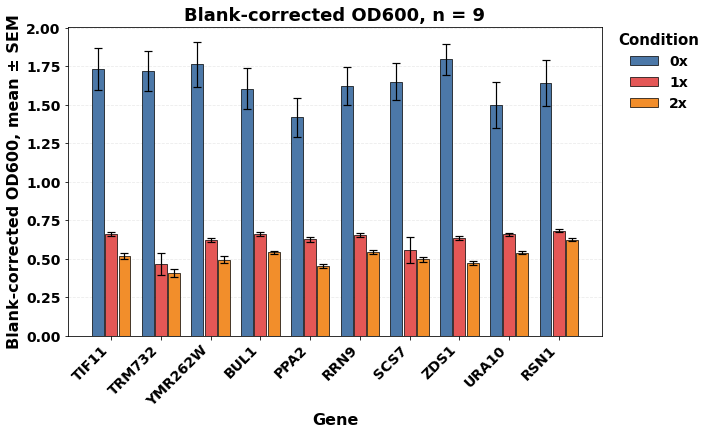

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/all_QTLs/blank_corrected_OD600_barplot.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/all_QTLs/blank_corrected_OD600_barplot.pdf


In [6]:
x = np.arange(
    len(strain_order)
)

number_of_conditions = len(
    conditions_to_plot
)

bar_width = (
    0.8 / number_of_conditions
)

offsets = (
    np.arange(number_of_conditions)
    - (number_of_conditions - 1) / 2
) * bar_width

fig, ax = plt.subplots(
    figsize=(
        max(
            11,
            0.8 * len(strain_order) + 2.5,
        ),
        6.5,
    )
)

for offset, condition in zip(
    offsets,
    conditions_to_plot,
):
    plot_data = (
        od_summary.loc[
            od_summary["condition"]
            == condition
        ]
        .set_index("sample_id")
        .reindex(
            strain_order["sample_id"]
        )
    )

    ax.bar(
        x + offset,
        plot_data["mean_OD600"],
        width=bar_width * 0.9,
        yerr=plot_data["OD600_error"],
        capsize=4,
        color=condition_colors[condition],
        edgecolor="black",
        linewidth=0.7,
        label=condition,
        error_kw={
            "elinewidth": 1.2,
            "capthick": 1.2,
        },
    )

ax.set_xticks(x)

ax.set_xticklabels(
    strain_order["gene"],
    rotation=45,
    ha="right",
)

plt.setp(
    ax.get_xticklabels(),
    fontweight="bold",
)

plt.setp(
    ax.get_yticklabels(),
    fontweight="bold",
)

ax.set_xlabel("Gene")

ax.set_ylabel(
    "Blank-corrected OD600, "
    f"mean ± {error_label}"
)

qtl_title = (
    ""
    if QTL_TO_PLOT is None
    else f"{QTL_TO_PLOT}: "
)

ax.set_title(
    f"{qtl_title}Blank-corrected OD600, "
    f"n = {n_title}"
)

legend = ax.legend(
    title="Condition",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False,
)

legend.get_title().set_fontweight(
    "bold"
)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
)

ax.set_axisbelow(True)

fig.subplots_adjust(
    right=0.80,
    bottom=0.22,
    top=0.88,
)

od_png_path = (
    RESULTS_DIR
    / "blank_corrected_OD600_barplot.png"
)

od_pdf_path = (
    RESULTS_DIR
    / "blank_corrected_OD600_barplot.pdf"
)

fig.savefig(
    od_png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    od_pdf_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {od_png_path}")
print(f"Saved: {od_pdf_path}")

In [7]:
control_summary = (
    od_summary.loc[
        od_summary["condition"]
        == CONTROL_CONDITION,
        [
            "sample_id",
            "gene",
            "qtl",
            "mean_OD600",
            "sem_OD600",
            "n",
        ],
    ]
    .rename(
        columns={
            "mean_OD600": "mean_OD600_0x",
            "sem_OD600": "sem_OD600_0x",
            "n": "n_0x",
        }
    )
)

treatment_summary = (
    od_summary.loc[
        od_summary["condition"]
        .isin(treatment_conditions),
        [
            "sample_id",
            "gene",
            "qtl",
            "condition",
            "mean_OD600",
            "sem_OD600",
            "n",
        ],
    ]
    .rename(
        columns={
            "condition": "treatment_condition",
            "mean_OD600": "mean_OD600_treatment",
            "sem_OD600": "sem_OD600_treatment",
            "n": "n_treatment",
        }
    )
)

fd_summary = treatment_summary.merge(
    control_summary,
    on=[
        "sample_id",
        "gene",
        "qtl",
    ],
    how="left",
    validate="many_to_one",
)

nonpositive = (
    (
        fd_summary[
            "mean_OD600_treatment"
        ]
        <= 0
    )
    |
    (
        fd_summary[
            "mean_OD600_0x"
        ]
        <= 0
    )
)

if nonpositive.any():
    display(
        fd_summary.loc[
            nonpositive
        ]
    )

    raise ValueError(
        "FD cannot be calculated because one or more "
        "strain-level mean OD600 values are zero or "
        "negative."
    )

fd_summary["FD"] = np.log2(
    fd_summary[
        "mean_OD600_treatment"
    ]
    / fd_summary[
        "mean_OD600_0x"
    ]
)

# Propagated SEM for log2(treatment/control).
fd_summary["FD_SEM"] = (
    np.sqrt(
        (
            fd_summary[
                "sem_OD600_treatment"
            ]
            / fd_summary[
                "mean_OD600_treatment"
            ]
        ) ** 2
        +
        (
            fd_summary[
                "sem_OD600_0x"
            ]
            / fd_summary[
                "mean_OD600_0x"
            ]
        ) ** 2
    )
    / np.log(2)
)

if ERROR_MODE == "sem":
    fd_summary["FD_error"] = (
        fd_summary["FD_SEM"]
    )

elif ERROR_MODE == "ci95":
    fd_summary["FD_error"] = (
        1.96 * fd_summary["FD_SEM"]
    )

fd_summary = (
    fd_summary
    .sort_values(
        [
            "treatment_condition",
            "sample_id",
        ],
        key=lambda column: (
            column.map(condition_value)
            if column.name
            == "treatment_condition"
            else column
        ),
        kind="stable",
    )
    .reset_index(drop=True)
)

display(fd_summary)

,sample_id,gene,qtl,treatment_condition,mean_OD600_treatment,sem_OD600_treatment,n_treatment,mean_OD600_0x,sem_OD600_0x,n_0x,FD,FD_SEM,FD_error
0,1,TIF11,all,1x,0.662611,0.012975,9,1.733667,0.139396,9,-1.387592,0.119391,0.119391
1,10,RSN1,all,1x,0.683389,0.011187,9,1.642333,0.151182,9,-1.264968,0.134888,0.134888
2,2,TRM732,all,1x,0.464944,0.073711,9,1.720000,0.132300,9,-1.887278,0.254220,0.254220
3,3,YMR262W,all,1x,0.624056,0.013976,9,1.763333,0.148675,9,-1.498559,0.125858,0.125858
4,4,BUL1,all,1x,0.659389,0.012159,9,1.605333,0.135137,9,-1.283671,0.124326,0.124326
5,5,PPA2,all,1x,0.627167,0.015275,9,1.419667,0.126861,9,-1.178631,0.133622,0.133622
6,6,RRN9,all,1x,0.654056,0.015647,9,1.623333,0.125040,9,-1.311474,0.116363,0.116363
7,7,SCS7,all,1x,0.557278,0.083117,9,1.650333,0.119055,9,-1.566289,0.239024,0.239024
8,8,ZDS1,all,1x,0.634500,0.010757,9,1.795333,0.098477,9,-1.500560,0.082828,0.082828
9,9,URA10,all,1x,0.658500,0.010710,9,1.497333,0.150422,9,-1.185140,0.146820,0.146820


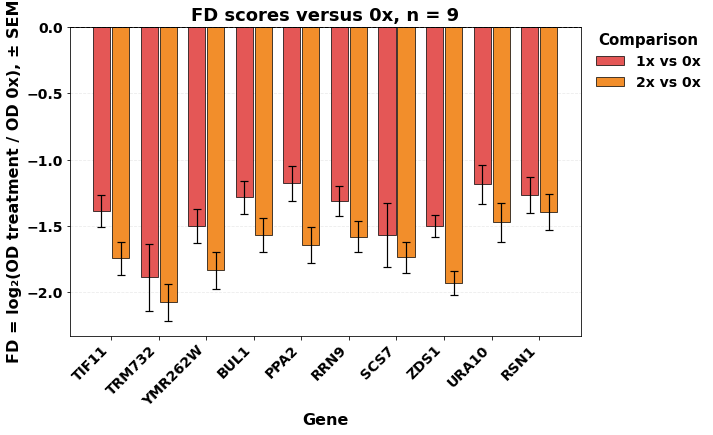

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/all_QTLs/blank_corrected_FD_barplot.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/all_QTLs/blank_corrected_FD_barplot.pdf


In [8]:
x = np.arange(
    len(strain_order)
)

number_of_treatments = len(
    treatment_conditions
)

bar_width = (
    0.8 / number_of_treatments
)

offsets = (
    np.arange(number_of_treatments)
    - (number_of_treatments - 1) / 2
) * bar_width

fig, ax = plt.subplots(
    figsize=(
        max(
            11,
            0.8 * len(strain_order) + 2.5,
        ),
        6.5,
    )
)

for offset, condition in zip(
    offsets,
    treatment_conditions,
):
    plot_data = (
        fd_summary.loc[
            fd_summary[
                "treatment_condition"
            ]
            == condition
        ]
        .set_index("sample_id")
        .reindex(
            strain_order["sample_id"]
        )
    )

    ax.bar(
        x + offset,
        plot_data["FD"],
        width=bar_width * 0.9,
        yerr=plot_data["FD_error"],
        capsize=4,
        color=condition_colors[condition],
        edgecolor="black",
        linewidth=0.7,
        label=f"{condition} vs 0x",
        error_kw={
            "elinewidth": 1.2,
            "capthick": 1.2,
        },
    )

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xticks(x)

ax.set_xticklabels(
    strain_order["gene"],
    rotation=45,
    ha="right",
)

plt.setp(
    ax.get_xticklabels(),
    fontweight="bold",
)

plt.setp(
    ax.get_yticklabels(),
    fontweight="bold",
)

ax.set_xlabel("Gene")

ax.set_ylabel(
    "FD = log₂(OD treatment / OD 0x), "
    f"± {error_label}"
)

ax.set_title(
    f"{qtl_title}FD scores versus 0x, "
    f"n = {n_title}"
)

legend = ax.legend(
    title="Comparison",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False,
)

legend.get_title().set_fontweight(
    "bold"
)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
)

ax.set_axisbelow(True)

fig.subplots_adjust(
    right=0.77,
    bottom=0.22,
    top=0.88,
)

fd_png_path = (
    RESULTS_DIR
    / "blank_corrected_FD_barplot.png"
)

fd_pdf_path = (
    RESULTS_DIR
    / "blank_corrected_FD_barplot.pdf"
)

fig.savefig(
    fd_png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    fd_pdf_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {fd_png_path}")
print(f"Saved: {fd_pdf_path}")

In [9]:
assert not od_summary.empty
assert not fd_summary.empty

assert np.isfinite(
    od_summary[
        [
            "mean_OD600",
            "sd_OD600",
            "sem_OD600",
        ]
    ]
    .dropna()
    .to_numpy()
).all()

assert np.isfinite(
    fd_summary[
        [
            "FD",
            "FD_SEM",
            "FD_error",
        ]
    ]
    .dropna()
    .to_numpy()
).all()

od_summary_path = (
    RESULTS_DIR
    / "blank_corrected_OD600_summary.tsv"
)

fd_summary_path = (
    RESULTS_DIR
    / "blank_corrected_FD_summary.tsv"
)

od_summary.to_csv(
    od_summary_path,
    sep="\t",
    index=False,
    float_format="%.10g",
)

fd_summary.to_csv(
    fd_summary_path,
    sep="\t",
    index=False,
    float_format="%.10g",
)

print("Saved summary files:")
print(od_summary_path)
print(fd_summary_path)

print("\nFD comparisons created:")

display(
    fd_summary.groupby(
        "treatment_condition",
        as_index=False,
    )
    .agg(
        strains=("sample_id", "nunique"),
        mean_FD=("FD", "mean"),
        minimum_FD=("FD", "min"),
        maximum_FD=("FD", "max"),
    )
)

print("All validation checks passed.")

Saved summary files:
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/all_QTLs/blank_corrected_OD600_summary.tsv
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/all_QTLs/blank_corrected_FD_summary.tsv

FD comparisons created:


,treatment_condition,strains,mean_FD,minimum_FD,maximum_FD
0,1x,10,-1.406416,-1.887278,-1.178631
1,2x,10,-1.696754,-2.074393,-1.395487


All validation checks passed.
